# Driver Drowsiness Detection

A real-time computer vision system that watches a face and raises an alarm when the eyes stay closed long enough to signal drowsiness. This is the core of a driver monitoring system.

Built from geometry, not deep learning, so no neural network is trained and no GPU is needed. A pre-built facial landmark detector locates the eyes, a simple ratio measures how open they are, and a small state machine distinguishes a blink from falling asleep.

**Pipeline:** video -> MediaPipe Face Mesh -> Eye Aspect Ratio -> drowsiness state machine -> annotated output.

---

## The Core Idea: Eye Aspect Ratio (EAR)

The eye's openness is captured by one number, the ratio of its vertical opening to its horizontal width:

- **Open Eye** - Lids far apart -> EAR high (~0.25-0.29)
- **Closed Eye** - Lids meet -> EAR collapses (~0.05)

Dividing by width makes it scale independent. Near or far from the camera, the same openness gives the same EAR. That's what lets the single fixed threshold work across a whole video.

In [1]:
import os
os.environ["GLOG_minloglevel"] = "3"
os.environ["GLOG_logtostderr"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["MEDIAPIPE_DISABLE_GPU"] = "0"

import sys, logging, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")
logging.getLogger("src.video").setLevel(logging.WARNING) 

import numpy as np
import matplotlib.pyplot as plt

import config
from src.video import FrameSource
from src.landmarks import LandmarkDetector
from src.ear import average_ear
from src.detector import DrowsinessDetector

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CLIP = "data/my_clip.mp4"
print(f"EAR Threshold: {config.EAR_THRESHOLD}")
print(f"Consecutive Frames for Drowsiness: {config.CONSECUTIVE_FRAMES}")

EAR Threshold: 0.15
Consecutive Frames for Drowsiness: 15


## Extracting the EAR Signal

We run every frame through the pipeline and record the EAR. This turns a videos into a one-dimensional signal (eye openness over time) which is where the blinks and the drowsy episode become visible.

In [2]:
landmarks = LandmarkDetector()
detector = DrowsinessDetector()

ears, drowsy_flags, closed_counts = [], [], []
src = FrameSource(CLIP)
fps = None

for frame in src:
    eyes = landmarks.get_eye_landmarks(frame)
    if eyes is None:
        #Carry forward the last EAR so the signal stays continuous
        ears = []
        if ears:
            ears.append(ears[-1])
        else:
            config.EAR_THRESHOLD
        drowsy_flags.append(False)
        closed_counts.append(0)
        continue
    ear = average_ear(eyes.left, eyes.right)
    result = detector.update(ear)
    ears.append(ear)
    drowsy_flags.append(result.drowsy)
    closed_counts.append(result.closed_frames)

landmarks.close()
fps = src.fps
ears = np.array(ears)
times = np.arange(len(ears)) / fps

print(f"Frames: {len(ears)}    |    Duration: {times[-1]:.1f}s   |   FPS: {fps:.1f}")
print(f"EAR Range: {ears.min():.3f} - {ears.max():.3f} (Mean {ears.mean():.3f})")
print(f"Drowsy Events: {detector.drowsy_events}")

I0000 00:00:1786829805.935526   17552 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1786829805.940353   17748 gl_context.cc:357] GL version: 3.0 (OpenGL ES 3.0 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) HD Graphics 2500 (IVB GT1)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1786829806.090221   17734 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786829806.111618   17735 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Frames: 635    |    Duration: 21.1s   |   FPS: 30.0
EAR Range: 0.041 - 0.286 (Mean 0.212)
Drowsy Events: 1


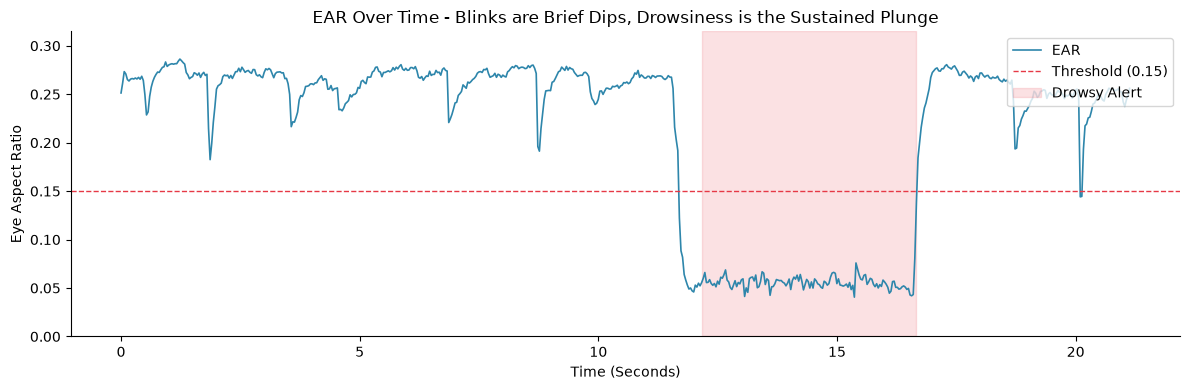

In [3]:
fig, ax = plt.subplots()

#EAR over time
ax.plot(times, ears, color = "#2E86AB", linewidth = 1.2, label = "EAR")

#Threshold line
ax.axhline(config.EAR_THRESHOLD, color = "#E63946", linestyle = "--", linewidth = 1, label = f"Threshold ({config.EAR_THRESHOLD})")

#Shade the drowsy regions
drowsy = np.array(drowsy_flags)
ax.fill_between(times, 0, ears.max()*1.1, where = drowsy, color = "#E63946", alpha = 0.15, label = "Drowsy Alert")

ax.set_xlabel("Time (Seconds)")
ax.set_ylabel("Eye Aspect Ratio")
ax.set_title("EAR Over Time - Blinks are Brief Dips, Drowsiness is the Sustained Plunge")
ax.set_ylim(0, ears.max()*1.1)
ax.legend(loc = "upper right")
plt.tight_layout()
plt.savefig("reports/figures/ear_timeline.png", dpi = 150, bbox_inches = "tight")
plt.show()

## What the Timeline Shows

Every blink and the one drowsy episode are visible in the signal.

- **Blinks** are the brief downward spikes across the first ~11 seconds. Several dip below the threshold becuase a blink and a closed eye look identical in depth.
- **Drowsiness** is the sustained plunge from ~11.7s to ~16.5s, where the EAR collapses to ~0.05 and stays there.

This is exactly why a depth threshold alone isn't enough. A naive "EAR below threshold = drowsy" rule would give false alarms on every blink that crosses the line. The system instead requires the closure to persist for 15 consecutive frames (~0.5s), so brief blinks are ignored and only sustained closure raises the alarm. The red shaded region, where the alert actually fired, begins just after the plunge, reflecting that half second confirmation window.

## Honest Limitations

The system works, but it is important to be clear about where it is brittle.

**1. The Threshold is person specific.** The 0.15 threshold was calibrated against *this subject's* EAR distribution. Eye shape, camera angle, and even glasses shift these values. A different person might need a different threshold. A production system wouls calibrate per user by measuring their open eye baseline for a few seconds ar startup.

**2. It assumes a clear, front-facing view.** Detection held at 100% on this well lit, front facing clip. Poor lighting, a turned hear, sunglasses, or a face far from the camera would degrade landmark detection, and no landmarks means no EAR.

**3. Fixed frame count threshold ignores frame rate variation.** "15 frames" assumes ~30fps. On a camera running at a very different rate, the half second assumption shifts. Conerting the threshold to a duration in seconds, and deriving frames from the measured fps, would make it robust to frame rate.

**4. EAR detects eye closure, not actual drowsiness itself.** Closed eyes are a strong proxy, but the system can't distinguish drowsiness from someone deliberately resting their eyes, looking down for a while, or other causes of sustained closure. Real driver monitoring systems combine EAR with head pose, yawning (Mouth Aspect Ratio), and blink rate trends.